In [28]:
import os
from typing import List, Annotated
from pydantic import BaseModel

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_classic.schema import Document
from langgraph.graph import StateGraph, END, START
from langchain_openai import ChatOpenAI

In [13]:
path = "text.txt"

loader = TextLoader(path)
docs = loader.load()

chunks = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap=100).split_documents(docs)
len(chunks)

11

In [15]:
model_name="gpt-5-nano-2025-08-07"
llm = ChatOpenAI(model_name=model_name, streaming=True)
embedding = OpenAIEmbeddings()

vectorstore = FAISS.from_documents(
    chunks, embedding
)

retriever= vectorstore.as_retriever()

In [53]:
class RAGState(BaseModel):
    retrieved_docs : list[Document] = []
    question : str
    response : str =  ""

In [61]:

def retriever_tools(state: RAGState) -> RAGState:
    docs = retriever.invoke(state.question)
    return RAGState(question=state.question, retrieved_docs=docs)

def responder(state: RAGState) -> RAGState:
    
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"Answer the question based on the context.\n\nContext:\n{context}\n\nQuestion: {state.question}"
    response = llm.invoke(prompt)
    return RAGState(question=state.question, retrieved_docs=state.retrieved_docs, answer=response.content)
    

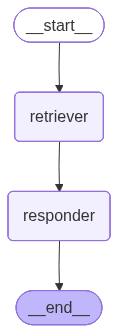

In [62]:
builder = StateGraph(RAGState)

builder.add_node("retriever", retriever_tools)
builder.add_node("responder", responder)

builder.add_edge(START, "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [63]:
response = graph.invoke({
    "question" : "Apa itu Vector Database Creation?"
})
response

{'retrieved_docs': [Document(id='e2219e9e-ce58-45e7-aed9-e34c42ba076f', metadata={'source': 'text.txt'}, page_content='coherent and contextually relevant responses. This process involves integrating the insights gleaned from various sources, ensuring accuracy and relevance, and crafting a response that is not only informative but also aligns with the userâ€™s original query, maintaining a natural and conversational tone. [...] 1. Vector Database Creation: RAG starts by converting an internal dataset into vectors and storing them in a vector database (or a database of your choosing).\\n2. User Input: A user'),
  Document(id='e1ad15cc-59eb-4eb5-8896-faa9260f8dd9', metadata={'source': 'text.txt'}, page_content='and storing them in a vector database (or a database of your choosing).\\n2. User Input: A user provides a query in natural language, seeking an answer or completion.\\n3. Information Retrieval: The retrieval mechanism scans the vector database to identify segments that are semanti